# MAE-Tiny

**MAE (Masked Autoencoder)** is a self-supervised learning (SSL) method based on **reconstruction in pixel space** : mask a large fraction of the image patches and train the model to reconstruct the missing pixels. No labels are needed.

Unlike contrastive methods (SimCLR, MoCo) which learn by comparing pairs in latent space, MAE learns by directly predicting raw RGB values of the masked patches. It is the vision analogue of masked language modeling (BERT).

Pre-trained on STL-10 unlabeled, evaluated on CIFAR-10 with both linear probe and full fine-tune.

Mask 75% of patches, reconstruct in pixel space. Encoder = ViT-Tiny (enc_d_model : 128, enc_num_layers : 6). Decoder = smaller ViT (dec_d_model : 64, dec_num_layers : 2 layers).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
import os

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "DATA"))
CKPT_DIR = './checkpoints/4_MAE'
os.makedirs(CKPT_DIR, exist_ok=True)

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device = {device}")

device = cuda


---
# 0. Dataset

STL-10 unlabeled (100k train / 8k test) for self-supervised pre-training. CIFAR-10 (50k train / 10k test) for downstream evaluation (linear probe + fine-tune).

In [2]:
BATCH_SIZE = 128
IMG_SIZE   = 32
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

transform_pretrain = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
transform_stl_test = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

pretrain_dataset = torchvision.datasets.STL10(root=DATA_DIR, split='unlabeled', download=True, transform=transform_pretrain)
train_dataset    = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=transform_train)
test_dataset     = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform_test)
stl_test_dataset = torchvision.datasets.STL10(root=DATA_DIR, split='test', download=True, transform=transform_stl_test)

pretrain_loader = DataLoader(pretrain_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)
train_loader    = DataLoader(train_dataset,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader     = DataLoader(test_dataset,     batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sample_img, _ = train_dataset[0]
CHANNELS, H, W = sample_img.shape
NUM_CLASSES    = len(train_dataset.classes)

print("── Pre-training (STL-10, self-supervised) ──")
print(f"  train (unlabeled) : {len(pretrain_dataset):>6}")
print(f"  test              : {len(stl_test_dataset):>6}")
print()
print("── Downstream (CIFAR-10, supervised) ──")
print(f"  train             : {len(train_dataset):>6}")
print(f"  test              : {len(test_dataset):>6}")
print()
print(f"CIFAR-10 classes : {train_dataset.classes}")

── Pre-training (STL-10, self-supervised) ──
  train (unlabeled) : 100000
  test              :   8000

── Downstream (CIFAR-10, supervised) ──
  train             :  50000
  test              :  10000

CIFAR-10 classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


---
# 1. MAE architecture

### Encoder : ViT-Tiny

| Step | Operation | Shape (symbolic) | Shape (numeric) |
|---|---|---|---|
| Input | image batch | $(B, \text{channels}, \text{img\_size}, \text{img\_size})$ | $(B, 3, 32, 32)$ |
| Patchify + linear projection | `patchify` + `nn.Linear(patch_dim, enc_d_model)` | $(B, n_{\text{patches}}, \text{enc\_d\_model})$ | $(B, 64, 128)$ |
| Add patch positional embeddings | $x + E_{\text{pos}}^{\text{patches}}$ | $(B, n_{\text{patches}}, \text{enc\_d\_model})$ | $(B, 64, 128)$ |
| Random masking (drop `mask_ratio`) | `random_masking` | $(B, n_{\text{visible}}, \text{enc\_d\_model})$ | $(B, 16, 128)$ |
| Prepend CLS token + CLS pos embed | $\text{cat}(\text{CLS}, x_{\text{visible}})$ | $(B, 1 + n_{\text{visible}}, \text{enc\_d\_model})$ | $(B, 17, 128)$ |
| `enc_num_layers` × Transformer blocks (Pre-LN) | `nn.TransformerEncoder` | $(B, 1 + n_{\text{visible}}, \text{enc\_d\_model})$ | $(B, 17, 128)$ |
| LayerNorm | `nn.LayerNorm(enc_d_model)` | $(B, 1 + n_{\text{visible}}, \text{enc\_d\_model})$ | $(B, 17, 128)$ |
| Encoder output | CLS + visible patches | $(B, 1 + n_{\text{visible}}, \text{enc\_d\_model})$ | $(B, 17, 128)$ |
---
| Hyperparameter | Symbol | Value |
|---|---|---|
| Encoder model dim | `enc_d_model` | 128 |
| Encoder heads | `enc_num_heads` | 4 |
| Encoder layers | `enc_num_layers` | 6 |
| Encoder FFN dim | `enc_d_ff` | 512 |

---

### Decoder : smaller ViT-Tiny

The decoder's only job is **pixel reconstruction** : a **low-semantic** task (predicting RGB values, no understanding of meaning required), unlike masked language modeling in BERT where each token carries high semantic content. Because the task is low-semantic, the decoder can be much smaller without hurting performance.

Following the MAE paper, the CLS token is **not** passed to the decoder — it is dropped right after the encoder. The decoder works only on the patches (visible + mask tokens).

| Step | Operation | Shape (symbolic) | Shape (numeric) |
|---|---|---|---|
| Encoder output | input to the decoder | $(B, 1 + n_{\text{visible}}, \text{enc\_d\_model})$ | $(B, 17, 128)$ |
| Project to decoder dim | `nn.Linear(enc_d_model, dec_d_model)` | $(B, 1 + n_{\text{visible}}, \text{dec\_d\_model})$ | $(B, 17, 64)$ |
| Drop CLS (decoder works on patches only) | `x[:, 1:, :]` | $(B, n_{\text{visible}}, \text{dec\_d\_model})$ | $(B, 16, 64)$ |
| Insert mask tokens | $\text{cat}(x_{\text{patches}}, [\text{mask}] \times n_{\text{masked}})$ | $(B, n_{\text{patches}}, \text{dec\_d\_model})$ | $(B, 64, 64)$ |
| Restore original patch order | `gather` with `ids_restore` | $(B, n_{\text{patches}}, \text{dec\_d\_model})$ | $(B, 64, 64)$ |
| Add decoder positional embeddings | $x + E_{\text{pos}}^{\text{dec}}$ | $(B, n_{\text{patches}}, \text{dec\_d\_model})$ | $(B, 64, 64)$ |
| `dec_num_layers` × Transformer blocks (Pre-LN) | `nn.TransformerEncoder` | $(B, n_{\text{patches}}, \text{dec\_d\_model})$ | $(B, 64, 64)$ |
| LayerNorm | `nn.LayerNorm(dec_d_model)` | $(B, n_{\text{patches}}, \text{dec\_d\_model})$ | $(B, 64, 64)$ |
| Project to pixel space | `nn.Linear(dec_d_model, patch_dim)` | $(B, n_{\text{patches}}, \text{patch\_dim})$ | $(B, 64, 48)$ |
| Decoder predictions | predicted patches | $(B, n_{\text{patches}}, \text{patch\_dim})$ | $(B, 64, 48)$ |

The `mask_token` is a single learnable vector $\in \mathbb{R}^{\text{dec\_d\_model}}$ inserted at every masked position before the decoder runs. The decoder predicts the pixels at each masked position from the context (the encoded visible patches).

| Hyperparameter | Symbol | Value |
|---|---|---|
| Decoder model dim | `dec_d_model` | 64 |
| Decoder heads | `dec_num_heads` | 4 |
| Decoder layers | `dec_num_layers` | 2 |
| Decoder FFN dim | `dec_d_ff` | 256 |

---

### Loss

MSE between predicted and true patches, **averaged only over the masked patches** (the loss on visible patches is ignored : the model has the trivial answer for them) :

$$\mathcal{L} = \frac{1}{|M|} \sum_{i \in M} \|\hat{x}_i - x_i\|_2^2$$

where $M$ is the set of masked patch indices, $\hat{x}_i$ is the decoder prediction, and $x_i$ is the true pixel patch.

---

### After pre-training

The decoder is **discarded**. Only the encoder is kept for downstream tasks (linear probe / fine-tune). The encoder is fed the **full image** (no masking) and the CLS feature $x[:, 0, :]$ is used as the image representation for classification.

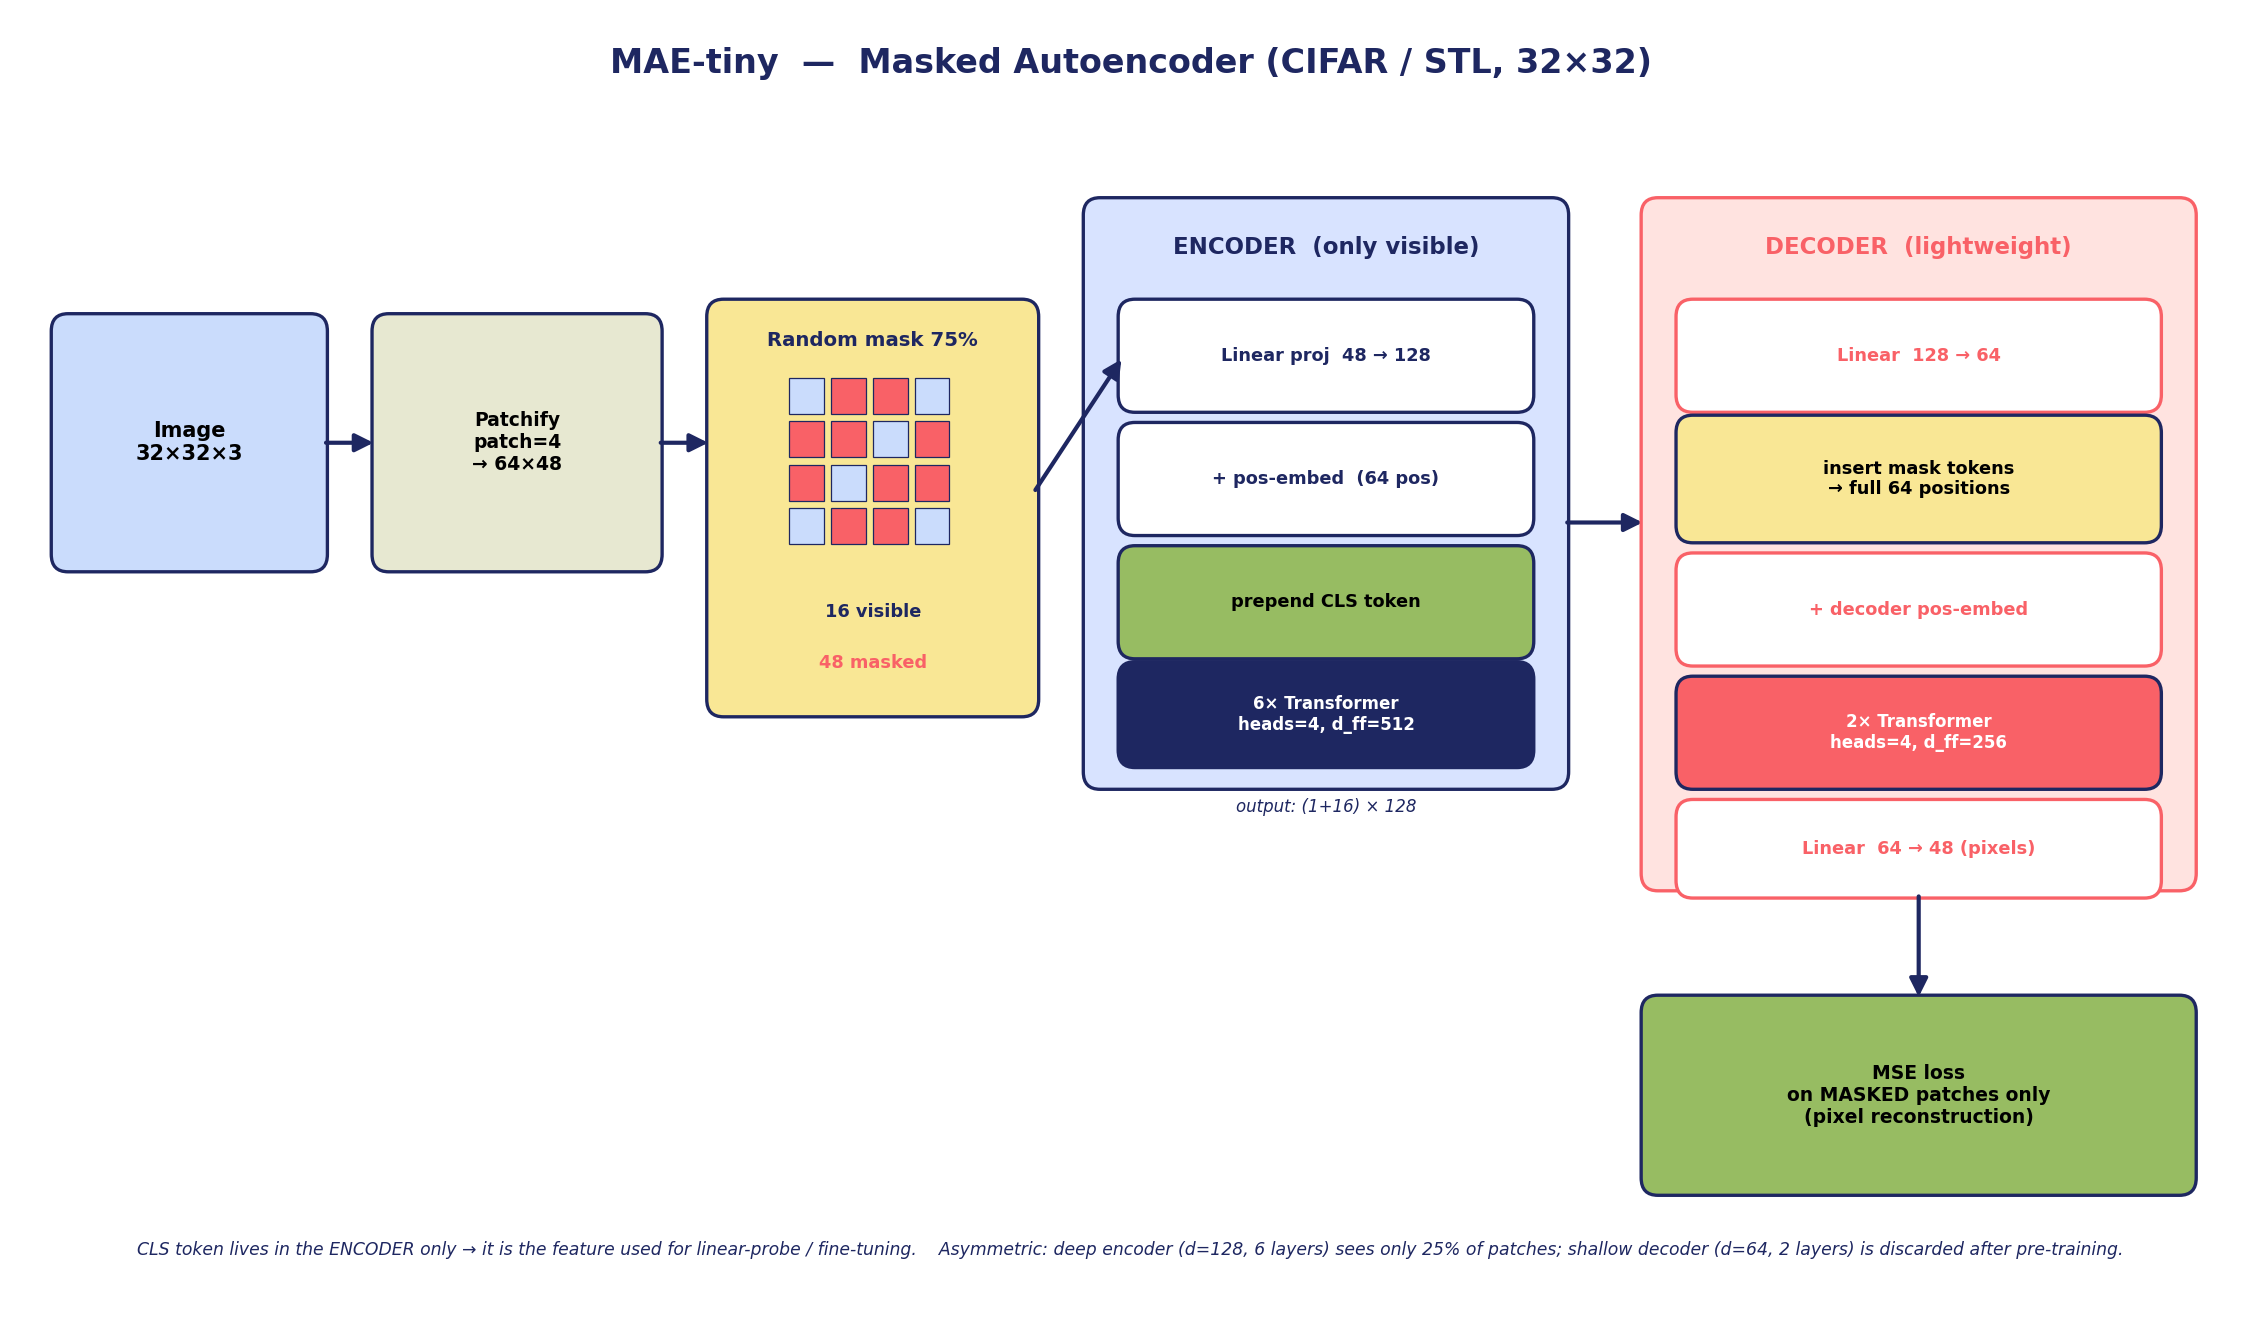

## Hyperparameters

In [3]:
# Hyperparameters

PATCH_SIZE     = 4
GRID_SIZE      = IMG_SIZE // PATCH_SIZE                # 8
N_PATCHES      = GRID_SIZE ** 2                        # 64
PATCH_DIM      = PATCH_SIZE ** 2 * CHANNELS            # 48

# Encoder 
ENC_D_MODEL    = 128
ENC_NUM_HEADS  = 4
ENC_NUM_LAYERS = 6
ENC_D_FF       = 4 * ENC_D_MODEL                       # 512

# Decoder
DEC_D_MODEL    = 64
DEC_NUM_HEADS  = 4
DEC_NUM_LAYERS = 2
DEC_D_FF       = 4 * DEC_D_MODEL                       # 256

MASK_RATIO     = 0.75
DROPOUT        = 0.1

PRETRAIN_EPOCHS = 20
PROBE_EPOCHS    = 60
FT_EPOCHS       = 60

print(f"N_PATCHES = {N_PATCHES}")
print(f"N_visible after masking = {int(N_PATCHES * (1 - MASK_RATIO))}")
print(f"N_masked                = {int(N_PATCHES * MASK_RATIO)}")

N_PATCHES = 64
N_visible after masking = 16
N_masked                = 48


In [4]:
def patchify(images, patch_size):  # images(B,C,H,W)
    B, C, H, W = images.shape
    P = patch_size
    x = images.reshape(B, C, H // P, P, W // P, P)
    x = x.permute(0, 2, 4, 3, 5, 1)
    x = x.reshape(B, (H // P) * (W // P), P * P * C)
    return x   # (B, N, patch_dim)


def unpatchify(patches, patch_size, channels):  # patches(B,N,patch_dim)
    B, N, _ = patches.shape
    P = patch_size
    h = w = int(N ** 0.5)
    x = patches.reshape(B, h, w, P, P, channels)
    x = x.permute(0, 5, 1, 3, 2, 4)
    x = x.reshape(B, channels, h * P, w * P)
    return x   # (B, C, H, W)


def unnormalize(img):
    mean = torch.tensor(MEAN).view(3, 1, 1).to(img.device)
    std  = torch.tensor(STD).view(3, 1, 1).to(img.device)
    return (img * std + mean).clamp(0, 1)

In [5]:
class MAE(nn.Module):

    def __init__(self, img_size, patch_size, channels, enc_d_model, enc_num_heads, enc_num_layers, enc_d_ff, dec_d_model, dec_num_heads, dec_num_layers, dec_d_ff, mask_ratio=0.75, dropout=0.1):
        super().__init__()
        self.patch_size  = patch_size
        self.channels    = channels
        self.mask_ratio  = mask_ratio
        self.n_patches   = (img_size // patch_size) ** 2 #64
        self.enc_d_model = enc_d_model
        patch_dim        = patch_size ** 2 * channels
        # Encoder
        self.patch_proj    = nn.Linear(patch_dim, enc_d_model)
        self.cls_token     = nn.Parameter(torch.randn(1, 1, enc_d_model) * 0.02)
        self.enc_pos_embed = nn.Parameter(torch.randn(1, self.n_patches + 1, enc_d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(d_model=enc_d_model, nhead=enc_num_heads, dim_feedforward=enc_d_ff, dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.encoder      = nn.TransformerEncoder(enc_layer, num_layers=enc_num_layers)
        self.encoder_norm = nn.LayerNorm(enc_d_model)
        # Decoder
        self.enc_to_dec    = nn.Linear(enc_d_model, dec_d_model)
        self.mask_token    = nn.Parameter(torch.randn(1, 1, dec_d_model) * 0.02)
        
        self.dec_pos_embed = nn.Parameter(torch.randn(1, self.n_patches, dec_d_model) * 0.02)

        dec_layer = nn.TransformerEncoderLayer(d_model=dec_d_model, nhead=dec_num_heads, dim_feedforward=dec_d_ff, dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.decoder      = nn.TransformerEncoder(dec_layer, num_layers=dec_num_layers)
        self.decoder_norm = nn.LayerNorm(dec_d_model)
        self.decoder_pred = nn.Linear(dec_d_model, patch_dim)

    def random_masking(self, x):  # x(B,N,enc_d_model)
        B, N, enc_d_model = x.shape
        n_keep  = int(N * (1 - self.mask_ratio))  # 16

        noise        = torch.rand(B, N, device=x.device)            # noise(B, N)
        ids_shuffle  = torch.argsort(noise, dim=1)                  # ids_shuffle(B, N)
        ids_restore  = torch.argsort(ids_shuffle, dim=1)            # ids_restore(B, N)
        ids_keep     = ids_shuffle[:, :n_keep]                      # ids_keep(B, n_keep)

        x_visible    = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, enc_d_model))  # x_visible(B, n_keep, enc_d_model)

        mask = torch.ones(B, N, device=x.device)  # mask(B,N)
        mask[:, :n_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)         # (B, N) : 1 where masked

        return x_visible, mask, ids_restore #x_visible(B,N_keep,enc_d_model) mask(B,N) ids_restore(B,N)

    def forward_encoder(self, images):  # images(B,C,H,W)
        B = images.shape[0]
        x = patchify(images, self.patch_size)               # x(B, N, patch_dim)
        x = self.patch_proj(x)                              # x(B, N, enc_d_model)
        x = x + self.enc_pos_embed[:, 1:, :]                # x(B, N, enc_d_model)

        x_visible, mask, ids_restore = self.random_masking(x)   # x_visible(B, n_keep, D), mask(B,N), ids_restore(B,N)

        cls = self.cls_token + self.enc_pos_embed[:, :1, :] # cls(1,1,enc_d_model)
        cls = cls.expand(B, -1, -1)                         # cls(B, 1, enc_d_model)

        x_visible = torch.cat([cls, x_visible], dim=1)      # x_visible(B, 1+n_keep, enc_d_model)
        x_visible = self.encoder(x_visible)                 # x_visible(B, 1+n_keep, enc_d_model)
        x_visible = self.encoder_norm(x_visible)            # x_visible(B, 1+n_keep, enc_d_model)
        return x_visible, mask, ids_restore           #x_visible(B,N_keep,enc_d_model) mask(B,N) ids_restore(B,N)

    def forward_decoder(self, x_visible, ids_restore):  # x_visible(B, 1+n_keep, enc_d_model), ids_restore(B,N)
        x = self.enc_to_dec(x_visible)                       # x(B, 1+n_keep, dec_d_model)

        B = x.shape[0]
        dec_d_model = x.shape[-1]
        N = ids_restore.shape[1]

        # drop CLS 
        x_pat = x[:, 1:, :]                                  # (B, n_keep, dec_d_model)
        n_keep = x_pat.shape[1]

        mask_tokens = self.mask_token.expand(B, N - n_keep, dec_d_model)  # mask_tokens(B, N_masked, dec_d_model)
        x_full = torch.cat([x_pat, mask_tokens], dim=1)      # (B, N, dec_d_model)

        x_full = torch.gather(x_full, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, dec_d_model))  # (B, N, dec_d_model)

        x_full = x_full + self.dec_pos_embed                 # (B, N, dec_d_model)

        x_full = self.decoder(x_full)                          # (B, N, dec_d_model)
        x_full = self.decoder_norm(x_full)                    # (B, N, dec_d_model)
        x_full = self.decoder_pred(x_full)                   # (B, N, patch_dim)

        return x_full                                        # (B, N, patch_dim)

    def forward_loss(self, images, pred, mask):         #images(B,C,H,W) pred(B,N,patch_dim) mask(B,N)
        target = patchify(images, self.patch_size)            # (B, N, patch_dim)
        loss   = (pred - target) ** 2                    
        loss   = loss.mean(dim=-1)                            # (B, N)
        loss   = (loss * mask).sum() / mask.sum()             # average over MASKED patches only
        return loss                              

    def forward(self, images):
        x_visible, mask, ids_restore = self.forward_encoder(images)
        pred = self.forward_decoder(x_visible, ids_restore)
        loss = self.forward_loss(images, pred, mask)
        return loss, pred, mask

---
# 2. Pre-training on STL-10

In [6]:
PRETRAIN_LR = 1.5e-4

mae = MAE(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    channels=CHANNELS,
    enc_d_model=ENC_D_MODEL,
    enc_num_heads=ENC_NUM_HEADS,
    enc_num_layers=ENC_NUM_LAYERS,
    enc_d_ff=ENC_D_FF,
    dec_d_model=DEC_D_MODEL,
    dec_num_heads=DEC_NUM_HEADS,
    dec_num_layers=DEC_NUM_LAYERS,
    dec_d_ff=DEC_D_FF,
    mask_ratio=MASK_RATIO,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(mae.parameters(), lr=PRETRAIN_LR, weight_decay=0.05)

params = sum(p.numel() for p in mae.parameters())

#Theoretical parameter count
enc_patch_proj = PATCH_DIM * ENC_D_MODEL + ENC_D_MODEL
enc_cls_token  = ENC_D_MODEL
enc_pos_embed  = (N_PATCHES + 1) * ENC_D_MODEL

enc_attn       = 4 * ENC_D_MODEL * ENC_D_MODEL + 4 * ENC_D_MODEL
enc_ffn        = 2 * ENC_D_MODEL * ENC_D_FF + ENC_D_FF + ENC_D_MODEL
enc_lns        = 2 * (2 * ENC_D_MODEL)
enc_per_block  = enc_attn + enc_ffn + enc_lns
enc_blocks     = ENC_NUM_LAYERS * enc_per_block
enc_final_norm = 2 * ENC_D_MODEL

dec_enc_to_dec = ENC_D_MODEL * DEC_D_MODEL + DEC_D_MODEL
dec_mask_token = DEC_D_MODEL
dec_pos_embed  = N_PATCHES * DEC_D_MODEL

dec_attn       = 4 * DEC_D_MODEL * DEC_D_MODEL + 4 * DEC_D_MODEL
dec_ffn        = 2 * DEC_D_MODEL * DEC_D_FF + DEC_D_FF + DEC_D_MODEL
dec_lns        = 2 * (2 * DEC_D_MODEL)
dec_per_block  = dec_attn + dec_ffn + dec_lns
dec_blocks     = DEC_NUM_LAYERS * dec_per_block
dec_final_norm = 2 * DEC_D_MODEL
dec_pred       = DEC_D_MODEL * PATCH_DIM + PATCH_DIM

encoder_params = enc_patch_proj + enc_cls_token + enc_pos_embed + enc_blocks + enc_final_norm
decoder_params = dec_enc_to_dec + dec_mask_token + dec_pos_embed + dec_blocks + dec_final_norm + dec_pred

params_th = encoder_params + decoder_params

print(f"encoder params : {encoder_params:,}")
print(f"decoder params : {decoder_params:,}")
print(f"empirical : {params:,}")
print(f"theory    : {params_th:,}")
print(f"match     : {params == params_th}")

encoder params : 1,204,608
decoder params : 115,632
empirical : 1,320,240
theory    : 1,320,240
match     : True


C:\Users\hugop\AppData\Local\Temp\ipykernel_19816\3647530415.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder      = nn.TransformerEncoder(enc_layer, num_layers=enc_num_layers)
C:\Users\hugop\AppData\Local\Temp\ipykernel_19816\3647530415.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder      = nn.TransformerEncoder(dec_layer, num_layers=dec_num_layers)


In [7]:
pretrain_losses = []
best_loss = float('inf')

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    mae.train()
    total_loss, n = 0.0, 0
    for images, _ in pretrain_loader:
        images = images.to(device)
        loss, _, _ = mae(images)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * images.size(0); n += images.size(0)
    avg = total_loss / n
    pretrain_losses.append(avg)
    print(f"Pre-train epoch {epoch:2d}/{PRETRAIN_EPOCHS} | MSE loss {avg:.4f}")

    torch.save({'epoch': epoch, 'model': mae.state_dict(), 'losses': pretrain_losses},
               os.path.join(CKPT_DIR, 'mae_last.pt'))
    if avg < best_loss:
        best_loss = avg
        torch.save({'epoch': epoch, 'model': mae.state_dict(), 'losses': pretrain_losses},
                   os.path.join(CKPT_DIR, 'mae_best.pt'))
        print(f"  -> best checkpoint saved (loss {best_loss:.4f})")

Pre-train epoch  1/20 | MSE loss 0.7027
  -> best checkpoint saved (loss 0.7027)
Pre-train epoch  2/20 | MSE loss 0.5170
  -> best checkpoint saved (loss 0.5170)
Pre-train epoch  3/20 | MSE loss 0.4423
  -> best checkpoint saved (loss 0.4423)
Pre-train epoch  4/20 | MSE loss 0.4024
  -> best checkpoint saved (loss 0.4024)
Pre-train epoch  5/20 | MSE loss 0.3827
  -> best checkpoint saved (loss 0.3827)
Pre-train epoch  6/20 | MSE loss 0.3695
  -> best checkpoint saved (loss 0.3695)
Pre-train epoch  7/20 | MSE loss 0.3609
  -> best checkpoint saved (loss 0.3609)
Pre-train epoch  8/20 | MSE loss 0.3535
  -> best checkpoint saved (loss 0.3535)
Pre-train epoch  9/20 | MSE loss 0.3480
  -> best checkpoint saved (loss 0.3480)
Pre-train epoch 10/20 | MSE loss 0.3432
  -> best checkpoint saved (loss 0.3432)
Pre-train epoch 11/20 | MSE loss 0.3396
  -> best checkpoint saved (loss 0.3396)
Pre-train epoch 12/20 | MSE loss 0.3356
  -> best checkpoint saved (loss 0.3356)
Pre-train epoch 13/20 | MSE 

## Curves

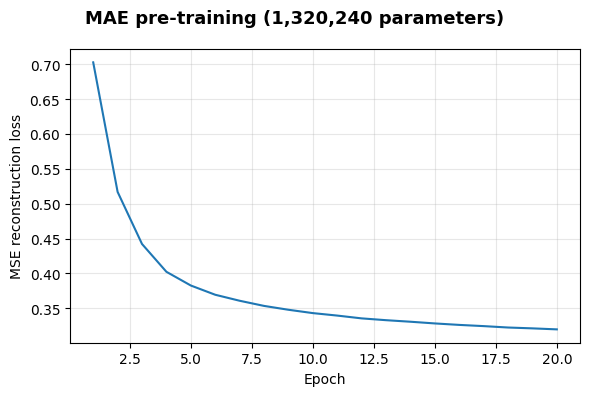

In [8]:
try:
    _ = pretrain_losses[0]
except (NameError, IndexError):
    ckpt = torch.load(os.path.join(CKPT_DIR, 'mae_last.pt'), map_location=device)
    pretrain_losses = ckpt['losses']

params = sum(p.numel() for p in mae.parameters())  

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(pretrain_losses) + 1), pretrain_losses)
plt.xlabel('Epoch'); plt.ylabel('MSE reconstruction loss')
plt.suptitle(f'MAE pre-training ({params:,} parameters)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 3. Results of the Pre-training

Plot 5 random reconstructions from the STL-10 test set

C:\Users\hugop\AppData\Local\Temp\ipykernel_19816\3647530415.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder      = nn.TransformerEncoder(enc_layer, num_layers=enc_num_layers)
C:\Users\hugop\AppData\Local\Temp\ipykernel_19816\3647530415.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder      = nn.TransformerEncoder(dec_layer, num_layers=dec_num_layers)


Loaded best MAE (epoch 20, loss 0.3198)


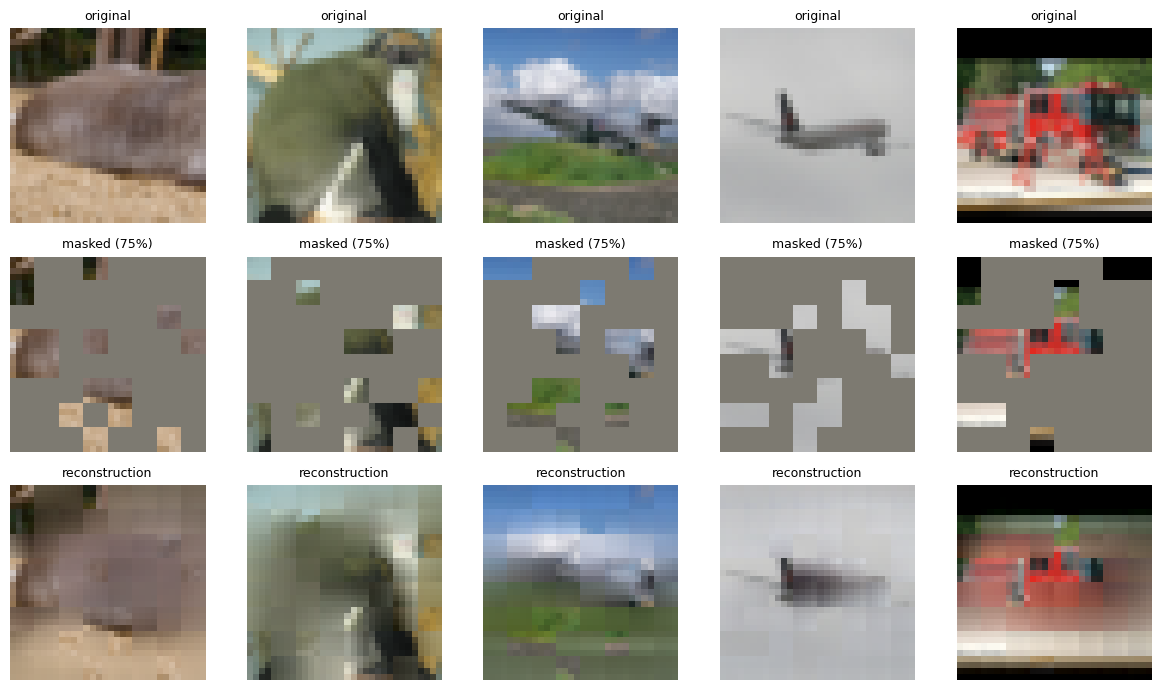

In [9]:
ckpt = torch.load(os.path.join(CKPT_DIR, 'mae_best.pt'), map_location=device)
mae = MAE(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    channels=CHANNELS,
    enc_d_model=ENC_D_MODEL,
    enc_num_heads=ENC_NUM_HEADS,
    enc_num_layers=ENC_NUM_LAYERS,
    enc_d_ff=ENC_D_FF,
    dec_d_model=DEC_D_MODEL,
    dec_num_heads=DEC_NUM_HEADS,
    dec_num_layers=DEC_NUM_LAYERS,
    dec_d_ff=DEC_D_FF,
    mask_ratio=MASK_RATIO,
    dropout=DROPOUT,
).to(device)
mae.load_state_dict(ckpt['model'])
print(f"Loaded best MAE (epoch {ckpt['epoch']}, loss {ckpt['losses'][-1]:.4f})")

mae.eval()
indices = torch.randint(0, len(stl_test_dataset), (5,))
fig, axes = plt.subplots(3, 5, figsize=(12, 7))

with torch.no_grad():
    for i, idx in enumerate(indices):
        img, _ = stl_test_dataset[idx]
        img_in = img.unsqueeze(0).to(device)
        
        _, pred, mask = mae(img_in)

        patches      = patchify(img_in, PATCH_SIZE)
        mask_3d      = mask.unsqueeze(-1)
        masked_patch = patches * (1 - mask_3d)
        masked_img   = unpatchify(masked_patch, PATCH_SIZE, CHANNELS)

        recon_patch  = patches * (1 - mask_3d) + pred * mask_3d
        recon_img    = unpatchify(recon_patch, PATCH_SIZE, CHANNELS)

        axes[0, i].imshow(unnormalize(img).permute(1, 2, 0).cpu().numpy())
        axes[0, i].set_title('original', fontsize=9); axes[0, i].axis('off')

        axes[1, i].imshow(unnormalize(masked_img[0]).permute(1, 2, 0).cpu().numpy())
        axes[1, i].set_title('masked (75%)', fontsize=9); axes[1, i].axis('off')

        axes[2, i].imshow(unnormalize(recon_img[0]).permute(1, 2, 0).cpu().numpy())
        axes[2, i].set_title('reconstruction', fontsize=9); axes[2, i].axis('off')

plt.tight_layout(); plt.show()

---
# 4. Encoder wrapper for probe / fine-tune

Runs the encoder on full images (no masking) and returns the CLS feature.

In [10]:
class MAEEncoder(nn.Module):

    def __init__(self, mae):
        super().__init__()
        self.patch_proj    = mae.patch_proj
        self.cls_token     = mae.cls_token
        self.enc_pos_embed = mae.enc_pos_embed
        self.encoder       = mae.encoder
        self.encoder_norm  = mae.encoder_norm
        self.patch_size    = mae.patch_size

    def forward(self, images):
        B = images.shape[0]
        x = patchify(images, self.patch_size)             # (B, N, patch_dim)
        x = self.patch_proj(x)                            # (B, N, enc_d_model)
        x = x + self.enc_pos_embed[:, 1:, :]              # patch positions only

        cls = self.cls_token + self.enc_pos_embed[:, :1, :]
        cls = cls.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)                  # (B, 1+N, enc_d_model)

        x = self.encoder(x)
        x = self.encoder_norm(x)
        return x[:, 0, :]                                  # CLS f (B, enc_d_model)


def build_mae_from_checkpoint():

    m = MAE(
        img_size=IMG_SIZE, 
        patch_size=PATCH_SIZE, 
        channels=CHANNELS,
        enc_d_model=ENC_D_MODEL, 
        enc_num_heads=ENC_NUM_HEADS,
        enc_num_layers=ENC_NUM_LAYERS, 
        enc_d_ff=ENC_D_FF,
        dec_d_model=DEC_D_MODEL, 
        dec_num_heads=DEC_NUM_HEADS,
        dec_num_layers=DEC_NUM_LAYERS, 
        dec_d_ff=DEC_D_FF,
        mask_ratio=MASK_RATIO, 
        dropout=DROPOUT,
    ).to(device)
    ckpt = torch.load(os.path.join(CKPT_DIR, 'mae_best.pt'), map_location=device)
    m.load_state_dict(ckpt['model'])
    return m

In [11]:
def slope_per_epoch(values, window=5):
    if len(values) < 2:
        return float('inf')
    w = min(window, len(values))
    y = np.array(values[-w:]); x = np.arange(w)
    return float(np.polyfit(x, y, 1)[0])


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()   
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

---
# 5. Linear probe on CIFAR-10

Freeze the encoder, train only a linear classifier head on the CLS feature.

In [12]:
class LinearProbe(nn.Module):
    def __init__(self, encoder, num_classes, d_model):
        super().__init__()
        self.encoder = encoder
        self.head    = nn.Linear(d_model, num_classes)
        for p in self.encoder.parameters():
            p.requires_grad = False

    def forward(self, images):
        with torch.no_grad():
            h = self.encoder(images)
        return self.head(h)


probe = LinearProbe(MAEEncoder(build_mae_from_checkpoint()), NUM_CLASSES, ENC_D_MODEL).to(device)

params    = sum(p.numel() for p in probe.head.parameters())
params_th = ENC_D_MODEL * NUM_CLASSES + NUM_CLASSES    
print(f"trainable (head) empirical : {params:,}")
print(f"trainable (head) theory    : {params_th:,}")
print(f"match                      : {params == params_th}")

trainable (head) empirical : 1,290
trainable (head) theory    : 1,290
match                      : True


C:\Users\hugop\AppData\Local\Temp\ipykernel_19816\3647530415.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder      = nn.TransformerEncoder(enc_layer, num_layers=enc_num_layers)
C:\Users\hugop\AppData\Local\Temp\ipykernel_19816\3647530415.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder      = nn.TransformerEncoder(dec_layer, num_layers=dec_num_layers)


In [13]:
PROBE_LR = 1e-3

optimizer = torch.optim.AdamW(probe.head.parameters(), lr=PROBE_LR, weight_decay=0.0)
criterion = nn.CrossEntropyLoss()

PATIENCE = 8
probe_train_losses, probe_test_losses = [], []
probe_train_accs,   probe_test_accs   = [], []
probe_best_acc = 0.0

for epoch in range(1, PROBE_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(probe, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(probe, test_loader, criterion)
    probe_train_losses.append(tr_loss); probe_test_losses.append(te_loss)
    probe_train_accs.append(tr_acc);   probe_test_accs.append(te_acc)
    print(f"epoch {epoch:2d}/{PROBE_EPOCHS} | train {tr_loss:.4f} {tr_acc*100:.1f}% | test {te_loss:.4f} {te_acc*100:.1f}%")

    if te_acc > probe_best_acc:
        probe_best_acc = te_acc
        torch.save({'epoch': epoch, 'model': probe.state_dict(),
                    'train_losses': probe_train_losses, 'test_losses': probe_test_losses,
                    'train_accs':   probe_train_accs,   'test_accs':   probe_test_accs},
                   os.path.join(CKPT_DIR, 'mae_probe_best.pt'))

    best_epoch = probe_test_accs.index(max(probe_test_accs))
    if (len(probe_test_accs) - 1 - best_epoch) >= PATIENCE:
        print(f"  early stop : converged (no improvement for {PATIENCE} epochs)")
        break

print(f"\nbest test acc : {max(probe_test_accs)*100:.2f}%")
print(f"converged at  : epoch {probe_test_accs.index(max(probe_test_accs))+1}")
print(f"final slope   : {slope_per_epoch([a*100 for a in probe_test_accs]):.3f} %/epoch")

epoch  1/60 | train 1.9920 26.2% | test 1.7947 33.3%
epoch  2/60 | train 1.8658 31.1% | test 1.7504 35.6%
epoch  3/60 | train 1.8361 31.9% | test 1.7299 37.0%
epoch  4/60 | train 1.8180 32.7% | test 1.7218 36.8%
epoch  5/60 | train 1.8072 33.1% | test 1.7239 36.4%
epoch  6/60 | train 1.8039 33.6% | test 1.7142 37.0%
epoch  7/60 | train 1.7951 33.5% | test 1.7116 37.5%
epoch  8/60 | train 1.7890 34.1% | test 1.7201 36.4%
epoch  9/60 | train 1.7862 34.0% | test 1.6902 37.8%
epoch 10/60 | train 1.7786 34.3% | test 1.7064 38.1%
epoch 11/60 | train 1.7820 34.2% | test 1.6818 38.8%
epoch 12/60 | train 1.7780 34.1% | test 1.6972 37.3%
epoch 13/60 | train 1.7739 34.4% | test 1.6835 38.2%
epoch 14/60 | train 1.7758 34.2% | test 1.6793 38.7%
epoch 15/60 | train 1.7723 34.3% | test 1.6768 39.0%
epoch 16/60 | train 1.7704 34.7% | test 1.6850 38.7%
epoch 17/60 | train 1.7694 34.3% | test 1.6754 39.3%
epoch 18/60 | train 1.7694 34.7% | test 1.6811 38.6%
epoch 19/60 | train 1.7656 34.8% | test 1.6629

MAE is known to perform poorly under linear probing : because the model is trained to reconstruct pixels (a low-semantic task), its features are **less linearly separable** than those of contrastive methods, even though they become strong once a non-linear head is fine-tuned

## Curves

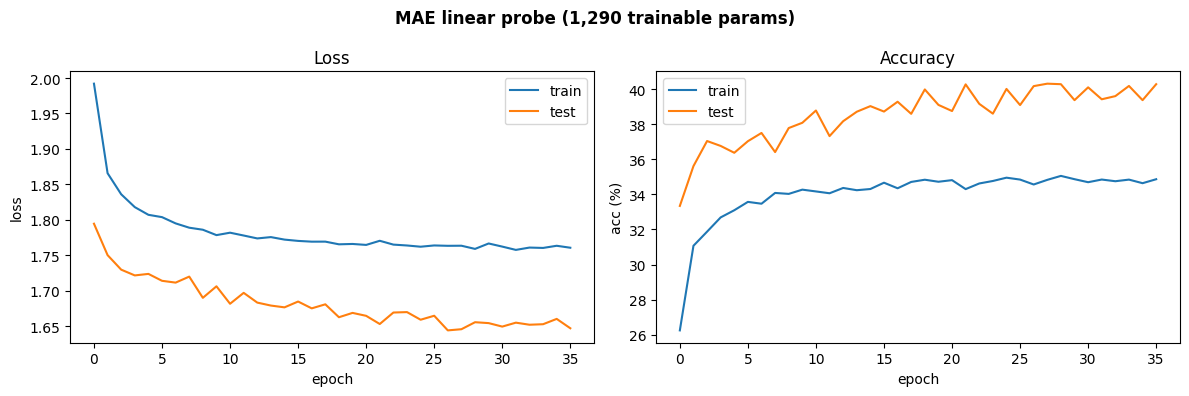

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(probe_train_losses, label='train'); ax1.plot(probe_test_losses, label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.set_title('Loss')
ax2.plot([a*100 for a in probe_train_accs], label='train'); ax2.plot([a*100 for a in probe_test_accs], label='test')
ax2.set_xlabel('epoch'); ax2.set_ylabel('acc (%)'); ax2.legend(); ax2.set_title('Accuracy')
plt.suptitle(f'MAE linear probe ({sum(p.numel() for p in probe.head.parameters()):,} trainable params)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Results

Plot 10 random predictions from the test set 

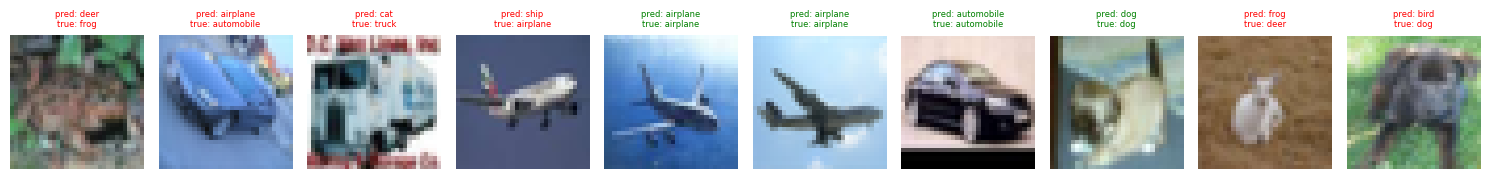

In [15]:
probe.eval()
classes = test_dataset.classes
indices = torch.randint(0, len(test_dataset), (10,))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, true_label = test_dataset[idx]
    with torch.no_grad():
        logits = probe(img.unsqueeze(0).to(device))
        pred   = logits.argmax(dim=1).item()
    axes[i].imshow(unnormalize(img).permute(1, 2, 0).cpu().numpy())
    color = 'green' if pred == true_label else 'red'
    axes[i].set_title(f"pred: {classes[pred]}\ntrue: {classes[true_label]}",
                       fontsize=6, color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

---
# 6. Full fine-tune on CIFAR-10

Unfreeze the encoder, train everything end-to-end.

In [16]:
class FullFineTune(nn.Module):
    def __init__(self, encoder, num_classes, d_model):
        super().__init__()
        self.encoder = encoder
        self.head    = nn.Linear(d_model, num_classes)

    def forward(self, images):
        h = self.encoder(images)
        return self.head(h)


ft = FullFineTune(MAEEncoder(build_mae_from_checkpoint()), NUM_CLASSES, ENC_D_MODEL).to(device)

params = sum(p.numel() for p in ft.parameters())

enc_patch_proj = PATCH_DIM * ENC_D_MODEL + ENC_D_MODEL              
enc_cls_token  = ENC_D_MODEL                                      
enc_pos_embed  = (N_PATCHES + 1) * ENC_D_MODEL                     

enc_attn       = 4 * ENC_D_MODEL * ENC_D_MODEL + 4 * ENC_D_MODEL
enc_ffn        = 2 * ENC_D_MODEL * ENC_D_FF + ENC_D_FF + ENC_D_MODEL
enc_lns        = 2 * (2 * ENC_D_MODEL)                          
enc_per_block  = enc_attn + enc_ffn + enc_lns
enc_blocks     = ENC_NUM_LAYERS * enc_per_block
enc_final_norm = 2 * ENC_D_MODEL                                  
head           = ENC_D_MODEL * NUM_CLASSES + NUM_CLASSES          

params_th = (enc_patch_proj + enc_cls_token + enc_pos_embed
             + enc_blocks + enc_final_norm + head)

print(f"trainable empirical : {params:,}")
print(f"trainable theory    : {params_th:,}")
print(f"match               : {params == params_th}")

trainable empirical : 1,205,898
trainable theory    : 1,205,898
match               : True


C:\Users\hugop\AppData\Local\Temp\ipykernel_19816\3647530415.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder      = nn.TransformerEncoder(enc_layer, num_layers=enc_num_layers)
C:\Users\hugop\AppData\Local\Temp\ipykernel_19816\3647530415.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder      = nn.TransformerEncoder(dec_layer, num_layers=dec_num_layers)


In [17]:
FT_LR = 1e-4

optimizer = torch.optim.AdamW(ft.parameters(), lr=FT_LR, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()

PATIENCE = 8
ft_train_losses, ft_test_losses = [], []
ft_train_accs,   ft_test_accs   = [], []
ft_best_acc = 0.0

for epoch in range(1, FT_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(ft, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(ft, test_loader, criterion)
    ft_train_losses.append(tr_loss); ft_test_losses.append(te_loss)
    ft_train_accs.append(tr_acc);   ft_test_accs.append(te_acc)
    print(f"epoch {epoch:2d}/{FT_EPOCHS} | train {tr_loss:.4f} {tr_acc*100:.1f}% | test {te_loss:.4f} {te_acc*100:.1f}%")

    if te_acc > ft_best_acc:
        ft_best_acc = te_acc
        torch.save({'epoch': epoch, 'model': ft.state_dict(),
                    'train_losses': ft_train_losses, 'test_losses': ft_test_losses,
                    'train_accs':   ft_train_accs,   'test_accs':   ft_test_accs},
                   os.path.join(CKPT_DIR, 'mae_ft_best.pt'))

    best_epoch = ft_test_accs.index(max(ft_test_accs))
    if (len(ft_test_accs) - 1 - best_epoch) >= PATIENCE:
        print(f"  early stop : converged (no improvement for {PATIENCE} epochs)")
        break

print(f"\nbest test acc : {max(ft_test_accs)*100:.2f}%")
print(f"converged at  : epoch {ft_test_accs.index(max(ft_test_accs))+1}")
print(f"final slope   : {slope_per_epoch([a*100 for a in ft_test_accs]):.3f} %/epoch")

epoch  1/60 | train 1.6338 39.7% | test 1.3367 51.4%
epoch  2/60 | train 1.3121 52.4% | test 1.1583 58.3%
epoch  3/60 | train 1.1745 57.8% | test 1.0398 63.1%
epoch  4/60 | train 1.0840 61.4% | test 0.9720 66.0%
epoch  5/60 | train 1.0242 63.5% | test 0.9416 67.0%
epoch  6/60 | train 0.9694 65.7% | test 0.8948 68.3%
epoch  7/60 | train 0.9333 66.8% | test 0.8425 70.3%
epoch  8/60 | train 0.8957 68.3% | test 0.8259 71.3%
epoch  9/60 | train 0.8689 69.0% | test 0.8088 72.0%
epoch 10/60 | train 0.8464 70.1% | test 0.7842 72.4%
epoch 11/60 | train 0.8238 71.0% | test 0.7613 73.3%
epoch 12/60 | train 0.8029 71.5% | test 0.7508 73.4%
epoch 13/60 | train 0.7851 72.2% | test 0.7379 74.7%
epoch 14/60 | train 0.7638 73.0% | test 0.7139 75.1%
epoch 15/60 | train 0.7505 73.4% | test 0.7274 74.8%
epoch 16/60 | train 0.7415 73.9% | test 0.6944 76.0%
epoch 17/60 | train 0.7233 74.4% | test 0.7043 75.6%
epoch 18/60 | train 0.7097 75.0% | test 0.6749 76.5%
epoch 19/60 | train 0.7019 75.2% | test 0.6758

## Curves

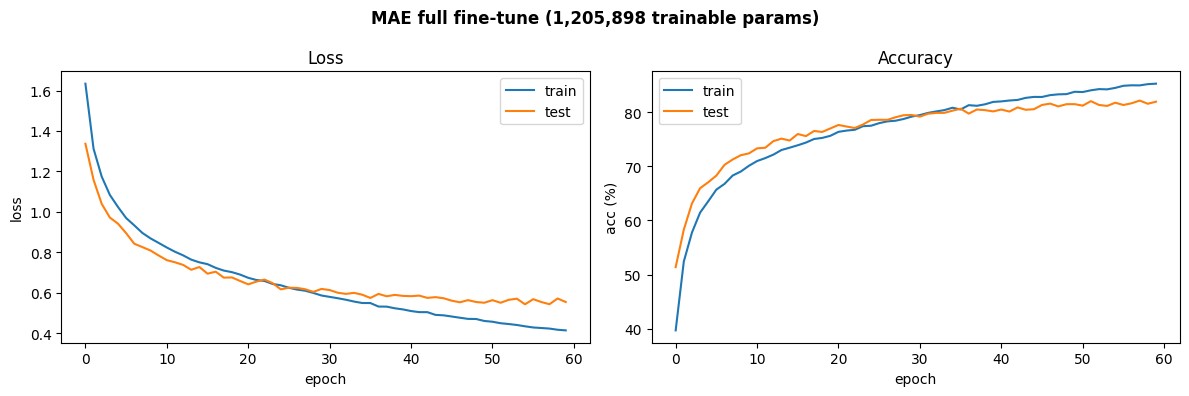

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ft_train_losses, label='train'); ax1.plot(ft_test_losses, label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.set_title('Loss')
ax2.plot([a*100 for a in ft_train_accs], label='train'); ax2.plot([a*100 for a in ft_test_accs], label='test')
ax2.set_xlabel('epoch'); ax2.set_ylabel('acc (%)'); ax2.legend(); ax2.set_title('Accuracy')
plt.suptitle(f'MAE full fine-tune ({sum(p.numel() for p in ft.parameters()):,} trainable params)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Results

Plot 10 random predictions from the test set 

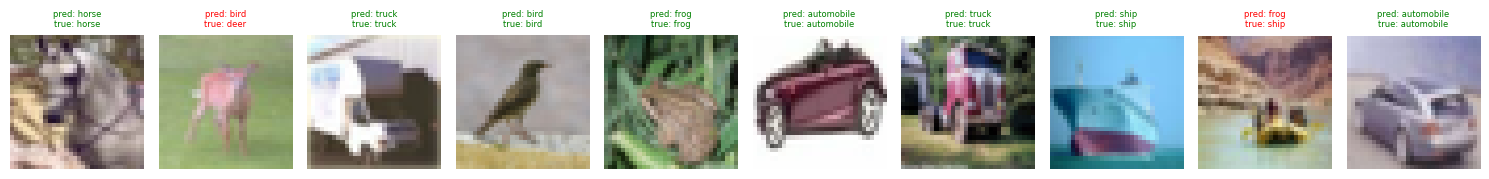

In [19]:
ft.eval()
classes = test_dataset.classes
indices = torch.randint(0, len(test_dataset), (10,))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, true_label = test_dataset[idx]
    with torch.no_grad():
        logits = ft(img.unsqueeze(0).to(device))
        pred   = logits.argmax(dim=1).item()
    axes[i].imshow(unnormalize(img).permute(1, 2, 0).cpu().numpy())
    color = 'green' if pred == true_label else 'red'
    axes[i].set_title(f"pred: {classes[pred]}\ntrue: {classes[true_label]}",
                       fontsize=6, color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()